# ¿Funciona la estrategia de TJR? — Réplica y backtest sobre datos reales

> Reconstrucción del experimento de **Revelio Trading**: se codifica el marco *Smart Money*
> de **TJR** y se somete a backtest para responder una sola pregunta: **¿gana dinero?**

**El relato de la estrategia:**

1. El precio está en tendencia.
2. **Barrido de liquidez** (*liquidity sweep*): rompe un máximo/mínimo previo y atrapa traders.
3. **Ruptura de estructura** (*break of structure*, BOS) en sentido contrario.
4. *(V2)* El precio **retrocede** a un **Fair Value Gap (FVG)**, un **Order Block (OB)** o la
   zona de **equilibrio** antes de entrar.
5. Entrada.

Suena lógico y repetible. Pero hay una diferencia enorme entre *una historia que parece tener
sentido* y *una estrategia rentable*. Este notebook construye el sistema completo y lo mide
sobre **datos reales de MetaTrader**.

---
### Datos
Los **12 mercados** del estudio: **4 pares × 3 timeframes** (5 min, 15 min, 1 h), de **enero 2016
a mayo 2026**. El notebook carga automáticamente las series que encuentre.

| | 5 min | 15 min | 1 h |
|---|---|---|---|
| EUR/USD · GBP/USD · USD/JPY · GBP/JPY | ✓ | ✓ | ✓ |

### Organización
| Sección | Contenido |
|---|---|
| 1 | Carga de los CSV reales |
| 2–6 | Motor: swings, sweep+BOS, FVG/OB/equilibrio, sesgo HTF, gestión multi-TP |
| 7 | La trampa matemática del *scaling parcial* |
| 8 | Anatomía de un setup (gráfico anotado) |
| 9–12 | V1, V1+sesgo, V2, V2+sesgo sobre todas las series |
| 13 | Comparativa y conclusiones |

> **Condiciones del test** (las del estudio original): parámetros de swing fijos y *razonables*
> (*in-sample*, el mejor caso), **sin costes** (spread, comisiones, slippage), riesgo **1%** por
> trade, una sola operación por activo. Es decir, el **escenario más favorable** posible.

## 0. Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

# ---- estilo de presentación (tema oscuro limpio) ----
BG="#1a1a2e"; UP="#00d4aa"; DN="#ff6b6b"; ACC="#4ecdc4"; TXT="#e8e8f0"
plt.rcParams.update({
    "figure.facecolor":BG,"axes.facecolor":BG,"savefig.facecolor":BG,
    "axes.edgecolor":"#444","axes.labelcolor":TXT,"text.color":TXT,
    "xtick.color":TXT,"ytick.color":TXT,"grid.color":"#444","grid.alpha":0.25,
    "axes.grid":True,"figure.dpi":110,"font.size":11,
    "axes.titlesize":13,"axes.titleweight":"bold"})
np.set_printoptions(suppress=True)

# ---- dónde están los CSV ----
# Pon los 12 CSV junto al notebook (o cambia DATA_DIR). Se intenta DATA_DIR y, si no,
# la carpeta de subida usada al generar este notebook.
DATA_DIR = "."
def find_csv(fn):
    for base in [DATA_DIR, "/mnt/user-data/uploads"]:
        p = os.path.join(base, fn)
        if os.path.exists(p): return p
    raise FileNotFoundError(f"No encuentro {fn}. Ajusta DATA_DIR.")

PAIRS = ["EURUSD", "GBPUSD", "USDJPY", "GBPJPY"]
TFS   = {"5min": "5", "15min": "15", "1h": "60"}      # sufijo del nombre de archivo
FILES = {(p, tf): f"{p}{suf}.csv" for p in PAIRS for tf, suf in TFS.items()}
START, END = "2016-01-01", "2026-05-31"

## 1. Datos — CSV reales de MetaTrader

Formato MT5 (sin cabecera): `fecha, hora, open, high, low, close, volumen`. Las series traen
relleno antiguo (hasta 1971) con velas planas; `load_mt5` **filtra al periodo de estudio**
(2016–2026) *antes* de parsear las fechas, para que la carga sea rápida.

In [ ]:
def load_mt5(path, start="2016-01-01", end="2026-05-31"):
    """Carga CSV estilo MetaTrader (sin cabecera):
    fecha, hora, open, high, low, close, volumen.  Filtra al periodo de estudio.
    Se filtra por texto de fecha ANTES de parsear (YYYY.MM.DD ordena lexicográficamente)."""
    df = pd.read_csv(path, header=None, usecols=range(6),
                     names=["d", "t", "open", "high", "low", "close"],
                     dtype={"d": str, "t": str})
    s = start.replace("-", "."); e = end.replace("-", ".")
    df = df[(df["d"] >= s) & (df["d"] <= e)]
    df.index = pd.to_datetime(df["d"] + " " + df["t"], format="%Y.%m.%d %H:%M")
    df = df[["open", "high", "low", "close"]]
    df = df[~df.index.duplicated(keep="first")].sort_index()
    df["hour"] = df.index.hour
    return df

Cargamos las **12 combinaciones** una sola vez y las dejamos en caché en `DATA`:

In [ ]:
DATA = {}
filas = []; faltan = []
for (p, tf), fn in FILES.items():
    try:
        path = find_csv(fn)
    except FileNotFoundError:
        faltan.append(fn); continue
    d = load_mt5(path, START, END)
    DATA[(p, tf)] = d
    filas.append(dict(Par=p, TF=tf, Velas=len(d),
                      Desde=d.index.min().date(), Hasta=d.index.max().date(),
                      **{"Precio min": round(d.close.min(),3),
                         "Precio max": round(d.close.max(),3)}))
resumen_datos = pd.DataFrame(filas)
print(f"Series cargadas: {len(DATA)} de {len(FILES)}")
if faltan: print("Faltan (no subidas):", ", ".join(faltan))
print("Total de velas cargadas:", f"{resumen_datos['Velas'].sum():,}")
resumen_datos

Series cargadas: 12 de 12
Total de velas cargadas: 4,049,119


,Par,TF,Velas,Desde,Hasta,Precio min,Precio max
0,EURUSD,5min,771114,2016-01-04,2026-05-29,0.954,1.255
1,EURUSD,15min,258328,2016-01-04,2026-05-29,0.954,1.255
2,EURUSD,1h,64675,2016-01-04,2026-05-29,0.954,1.255
3,GBPUSD,5min,672967,2016-01-04,2026-01-23,1.040,1.501
4,GBPUSD,15min,226529,2016-01-04,2026-01-23,1.040,1.501
5,GBPUSD,1h,64402,2016-01-04,2026-05-29,1.040,1.501
6,USDJPY,5min,648103,2016-01-04,2026-05-29,99.586,161.947
7,USDJPY,15min,258637,2016-01-04,2026-05-30,99.586,161.939
8,USDJPY,1h,64681,2016-01-04,2026-05-30,99.722,161.939
9,GBPJPY,5min,717008,2016-01-04,2026-05-29,123.455,214.663


## 2. Primitivas Smart Money: swings y FVG

**Swing points (fractales).** Una vela es *swing high* si su máximo es el mayor en una ventana de
`left` velas a la izquierda y `right` a la derecha. Aquí aparece el primer problema del video:
**¿cuántas velas mirar?** `(6,2)`, `(12,4)`, `(20,10)`… cada elección cambia los trades. La
detección está **vectorizada** (necesario para las ~770k velas de las series de 5 min) y un swing
**solo se confirma `right` velas después** (sin *look-ahead*).

**Fair Value Gap (FVG).** Desequilibrio de 3 velas: alcista si `low[i] > high[i-2]`,
bajista si `high[i] < low[i-2]`.

In [ ]:
def swing_points(high, low, left, right):
    """Fractal swings (vectorizado). Devuelve listas (idx, level, conf_idx)
    para highs y lows. Un swing se confirma `right` velas después (sin look-ahead)."""
    from numpy.lib.stride_tricks import sliding_window_view
    n = len(high)
    w = left + right + 1
    if n < w:
        return [], []
    hv = sliding_window_view(high, w)          # filas: ventanas; centro = inicio+left
    lv = sliding_window_view(low, w)
    rmax = hv.max(1); rmin = lv.min(1)
    centers = np.arange(left, n - right)
    is_h = high[left:n-right] >= rmax
    is_l = low[left:n-right] <= rmin
    hi_idx = centers[is_h]; lo_idx = centers[is_l]
    highs = [(int(i), float(high[i]), int(i + right)) for i in hi_idx]
    lows = [(int(i), float(low[i]), int(i + right)) for i in lo_idx]
    return highs, lows


def find_fvgs(o, h, l, c):
    """3-candle imbalance. bull: low[i] > high[i-2]; bear: high[i] < low[i-2].
    Returns dict idx-> (kind, top, bottom)."""
    fvg = {}
    for i in range(2, len(h)):
        if l[i] > h[i-2]:
            fvg[i] = ("bull", l[i], h[i-2])
        elif h[i] < l[i-2]:
            fvg[i] = ("bear", l[i-2], h[i])
    return fvg

## 3. Sesgo de temporalidad superior (HTF bias)

Regla de TJR: no operar salvo que el **diario y el semanal** estén alineados con la dirección del
trade. Aproximamos la tendencia de cada temporalidad con el cruce de dos EMAs sobre el *resample*
a diario (`D`) y semanal (`W`).

In [ ]:
def htf_bias(df, rule):
    """Trend per HTF candle via higher-high/higher-low structure (EMA proxy)."""
    htf = df["close"].resample(rule).last().dropna()
    ema_f = htf.ewm(span=10).mean()
    ema_s = htf.ewm(span=30).mean()
    bias = np.where(ema_f > ema_s, 1, -1)
    bias = pd.Series(bias, index=htf.index)
    return bias.reindex(df.index, method="ffill").fillna(0)

## 4. Configuración y estructura de la operación

Un único `Config` controla **las cuatro versiones** con dos interruptores: `use_retrace`
(entrada por retroceso a FVG/OB = V2) y `use_bias` (filtro diario+semanal). Gestión tal como la
enseña TJR: **SL más allá de la mecha del barrido**, **3 take profits** (1R/2R/3R), **1/3 de la
posición en cada uno**, **SL a break-even tras TP1**, riesgo **1%** y **una operación por activo**.

In [ ]:
@dataclass
class Config:
    left: int = 6
    right: int = 2
    sweep_lookback: int = 40
    bos_window: int = 20
    retrace_window: int = 30      # V2 wait for pullback
    risk_pct: float = 0.01
    tp_mults: tuple = (1.0, 2.0, 3.0)
    sl_buffer: float = 0.0
    use_retrace: bool = False     # V2 toggle
    use_bias: bool = False        # bias filter toggle
    session_hours: tuple = (7, 20)  # skip dead hours (UTC-ish)
    spread: float = 0.0
    version: str = "V1"


@dataclass
class Trade:
    side: int; entry_idx: int; entry: float; sl: float
    tps: list; exit_idx: int = -1; r: float = 0.0; etype: str = ""

## 5. Motor de backtest

Recorre las velas manteniendo el estado: swings activos → **barrido** → espera **BOS** → *(V2)*
espera **retroceso** a FVG/OB en descuento/premium → entra si pasa el **filtro de sesión** y, en su
caso, el **sesgo HTF**. La gestión intrabar resuelve los choques SL/TP de forma **conservadora**
(si en la misma vela cabían ambos, asume que tocó el SL primero).

In [ ]:
def backtest(df, cfg: Config):
    o = df["open"].values; h = df["high"].values
    l = df["low"].values; c = df["close"].values
    hour = df["hour"].values
    n = len(df)

    highs, lows = swing_points(h, l, cfg.left, cfg.right)
    fvgs = find_fvgs(o, h, l, c)
    # claves de FVG ordenadas -> permite recortar por rango con searchsorted (rápido)
    fvg_keys = np.array(sorted(fvgs.keys()), dtype=np.int64)
    fvg_vals = [fvgs[int(k)] for k in fvg_keys]
    # quick index of confirmed swings by confirmation bar
    hi_by_conf = {}; lo_by_conf = {}
    for i, lv, ci in highs: hi_by_conf.setdefault(ci, []).append((i, lv))
    for i, lv, ci in lows: lo_by_conf.setdefault(ci, []).append((i, lv))

    bias = htf_bias(df, "W") * 0 + 0
    if cfg.use_bias:
        bw = htf_bias(df, "W").values; bd = htf_bias(df, "D").values
        bias_arr = np.where(bw == bd, bw, 0)
    else:
        bias_arr = np.zeros(n)

    active_hi = []  # (idx, level)  not yet swept
    active_lo = []
    pending = None  # dict describing a setup awaiting BOS / retrace
    trade = None
    trades = []
    equity = 10000.0
    eq0 = equity
    eq_curve = [equity]; eq_idx = [df.index[0]]

    for i in range(cfg.right + 1, n):
        # register newly-confirmed swings
        for (si, lv) in hi_by_conf.get(i, []): active_hi.append((si, lv))
        for (si, lv) in lo_by_conf.get(i, []): active_lo.append((si, lv))
        active_hi = [(si, lv) for (si, lv) in active_hi if si >= i - cfg.sweep_lookback]
        active_lo = [(si, lv) for (si, lv) in active_lo if si >= i - cfg.sweep_lookback]

        # ---- manage open trade (intrabar, SL-first conservative) ----
        if trade is not None:
            t = trade
            done = False
            stopped = False
            if t.side == 1:  # long
                if l[i] <= t.sl:           # SL checked first (conservative)
                    stopped = True; done = True
                else:
                    for k, tp in enumerate(t.tps):
                        if not t.tp_hit[k] and h[i] >= tp:
                            t.tp_hit[k] = True
                            if k == 0: t.sl = t.entry  # move to break-even
                    if all(t.tp_hit): done = True
            else:                          # short
                if h[i] >= t.sl:
                    stopped = True; done = True
                else:
                    for k, tp in enumerate(t.tps):
                        if not t.tp_hit[k] and l[i] <= tp:
                            t.tp_hit[k] = True
                            if k == 0: t.sl = t.entry
                    if all(t.tp_hit): done = True
            if done:
                t.exit_idx = i
                t.r = _trade_R(t, stopped)
                equity += eq0 * cfg.risk_pct * t.r   # riesgo fijo: 1% del capital inicial por trade
                trades.append(t)
                trade = None

        eq_curve.append(equity); eq_idx.append(df.index[i])

        if trade is not None:
            continue
        in_session = cfg.session_hours[0] <= hour[i] <= cfg.session_hours[1]

        # ---- pending setup: look for BOS then (optionally) retrace ----
        if pending is not None:
            if i - pending["sweep_bar"] > cfg.bos_window + (cfg.retrace_window if cfg.use_retrace else 0):
                pending = None
            else:
                p = pending
                if not p["bos"]:
                    if p["side"] == -1 and c[i] < p["struct"]:
                        p["bos"] = True; p["bos_bar"] = i
                        p["leg_top"] = p["sweep_price"]; p["leg_bot"] = min(l[p["sweep_bar"]:i+1])
                    elif p["side"] == 1 and c[i] > p["struct"]:
                        p["bos"] = True; p["bos_bar"] = i
                        p["leg_bot"] = p["sweep_price"]; p["leg_top"] = max(h[p["sweep_bar"]:i+1])
                    if p["bos"] and cfg.use_retrace:
                        # precomputar UNA vez: equilibrio, OB y FVGs dentro del impulso
                        rng_leg = p["leg_top"] - p["leg_bot"]
                        p["eq"] = p["leg_bot"] + 0.5 * rng_leg
                        want = "bear" if p["side"] == -1 else "bull"
                        lo_j = int(np.searchsorted(fvg_keys, p["sweep_bar"], "left"))
                        hi_j = int(np.searchsorted(fvg_keys, i, "right"))
                        p["zones"] = [fvg_vals[j] for j in range(lo_j, hi_j)
                                      if fvg_vals[j][0] == want]
                        p["ob"] = (h[i-1] if p["side"] == -1 else l[i-1]) if i > 0 \
                            else (p["leg_top"] if p["side"] == -1 else p["leg_bot"])
                if p["bos"]:
                    enter = False; etype = "sweep_bos"; px = c[i]
                    if not cfg.use_retrace:
                        if i == p["bos_bar"]:
                            enter = True
                    else:
                        eq = p["eq"]; zones = p["zones"]
                        if p["side"] == -1:
                            ob_top = p["ob"]
                            prem = h[i] >= eq
                            hit_z = any(z[2] <= h[i] <= z[1] for z in zones) or (prem and h[i] >= ob_top*0.999)
                            if prem and hit_z:
                                enter = True; px = c[i]; etype = "ob" if not zones else "fvg"
                        else:
                            ob_bot = p["ob"]
                            disc = l[i] <= eq
                            hit_z = any(z[2] <= l[i] <= z[1] for z in zones) or (disc and l[i] <= ob_bot*1.001)
                            if disc and hit_z:
                                enter = True; px = c[i]; etype = "ob" if not zones else "fvg"
                    if enter and in_session:
                        ok_bias = (not cfg.use_bias) or (bias_arr[i] == p["side"])
                        if ok_bias:
                            side = p["side"]
                            if side == -1:
                                entry = px; sl = p["sweep_price"] * (1 + cfg.sl_buffer)
                                risk = sl - entry
                                if risk > 0:
                                    tps = [entry - m * risk for m in cfg.tp_mults]
                                    trade = _open(side, i, entry, sl, tps, risk, equity, cfg, etype)
                            else:
                                entry = px; sl = p["sweep_price"] * (1 - cfg.sl_buffer)
                                risk = entry - sl
                                if risk > 0:
                                    tps = [entry + m * risk for m in cfg.tp_mults]
                                    trade = _open(side, i, entry, sl, tps, risk, equity, cfg, etype)
                        pending = None

        # ---- detect new sweep (only if no pending/trade) ----
        if pending is None and trade is None:
            # bearish: sweep of a swing high
            for (si, lv) in sorted(active_hi, key=lambda x: -x[1]):
                if h[i] > lv and c[i] < lv:
                    structs = [x[1] for x in active_lo if x[0] > si]
                    if structs:
                        pending = dict(side=-1, sweep_bar=i, sweep_price=h[i],
                                       struct=min(structs), bos=False)
                    active_hi = [x for x in active_hi if x[0] != si]
                    break
            if pending is None:
                for (si, lv) in sorted(active_lo, key=lambda x: x[1]):
                    if l[i] < lv and c[i] > lv:
                        structs = [x[1] for x in active_hi if x[0] > si]
                        if structs:
                            pending = dict(side=1, sweep_bar=i, sweep_price=l[i],
                                           struct=max(structs), bos=False)
                        active_lo = [x for x in active_lo if x[0] != si]
                        break

    eq = pd.Series(eq_curve, index=pd.DatetimeIndex(eq_idx))
    return trades, eq

## 6. Resultado en R de cada trade

Compounding de **fracción fija**: `equity *= (1 + 1% · R)`. El resultado en R con parciales de 1/3
y SL a break-even tras TP1 es lo que da sentido a toda la discusión de la siguiente sección.

In [ ]:
def _open(side, i, entry, sl, tps, risk, equity, cfg, etype):
    t = Trade(side, i, entry, sl, list(tps), etype=etype)
    t.risk = risk
    t.sl0 = sl           # stop inicial (la mecha del barrido) antes del break-even
    t.tp_hit = [False, False, False]
    return t


def _trade_R(t, stopped):
    """R outcome with 1/3 partials and SL->BE after TP1 (matches TJR's math)."""
    if t.tp_hit[2]:
        return (1/3)*1 + (1/3)*2 + (1/3)*3      # +2.0R  (all targets)
    if t.tp_hit[1]:
        return (1/3)*1 + (1/3)*2 + (1/3)*0      # +1.0R  (last third to BE)
    if t.tp_hit[0]:
        return (1/3)*1 + (2/3)*0                # +0.33R (rest to BE)
    return -1.0                                 # full stop, no TP


def summarize(trades, eq):
    if not trades:
        return dict(trades=0, ret_pct=0, win=0, tp3=0, pf=0, total_R=0, by_type={})
    rs = np.array([t.r for t in trades])
    wins = rs[rs > 0]; losses = rs[rs < 0]
    pf = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else np.inf
    ret = eq.iloc[-1] / eq.iloc[0] - 1
    tp3 = np.mean([t.tp_hit[2] for t in trades])
    by_type = {}
    for et in set(t.etype for t in trades):
        sub = [t.r for t in trades if t.etype == et]
        by_type[et] = dict(n=len(sub), R=float(np.sum(sub)))
    return dict(trades=len(trades), ret_pct=ret*100, win=(rs > 0).mean()*100,
                tp3=tp3*100, pf=pf, total_R=float(rs.sum()), by_type=by_type)

## 7. La trampa matemática del *scaling parcial*

Pareces dividir el trade en 1:1, 1:2 y 1:3. **Falso.** Como cierras solo **1/3** en cada objetivo:

- TP1 → `1/3 · 1R = 0.33R`
- + TP2 → `1/3 · 2R = 0.67R`  ⟹ acumulado **1.0R** (¡lo mismo que pierdes en un solo stop!)
- + TP3 → `1/3 · 3R = 1.0R`  ⟹ acumulado **2.0R** (el mejor caso absoluto)

Mientras tanto, **cada pérdida se come 1R completo**, y el TP3 casi nunca se alcanza.

Stop (sin TP)          -> -1.00R
Solo TP1               -> +0.33R
TP1+TP2                -> +1.00R
TP1+TP2+TP3            -> +2.00R
TP3 a 10R (jackpot)    -> +4.33R


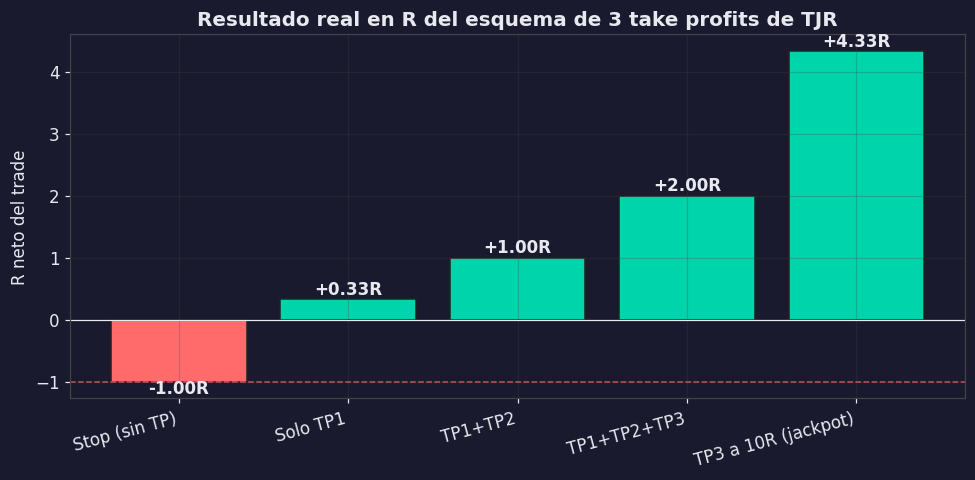

In [ ]:
def trade_R(tp1, tp2, tp3, hit1, hit2, hit3):
    if hit3: return (1/3)*tp1 + (1/3)*tp2 + (1/3)*tp3
    if hit2: return (1/3)*tp1 + (1/3)*tp2 + (1/3)*0
    if hit1: return (1/3)*tp1 + (2/3)*0
    return -1.0

casos = {
    "Stop (sin TP)":      trade_R(1,2,3, 0,0,0),
    "Solo TP1":           trade_R(1,2,3, 1,0,0),
    "TP1+TP2":            trade_R(1,2,3, 1,1,0),
    "TP1+TP2+TP3":        trade_R(1,2,3, 1,1,1),
    "TP3 a 10R (jackpot)":trade_R(1,2,10, 1,1,1),
}
for k,v in casos.items(): print(f"{k:22s} -> {v:+.2f}R")

fig, ax = plt.subplots(figsize=(9,4.5))
ks=list(casos); vs=list(casos.values())
ax.bar(ks, vs, color=[DN if v<0 else UP for v in vs], edgecolor="#222")
ax.axhline(0, color=TXT, lw=.8); ax.axhline(-1, color=DN, ls="--", lw=1, alpha=.7)
ax.set_title("Resultado real en R del esquema de 3 take profits de TJR")
ax.set_ylabel("R neto del trade"); plt.xticks(rotation=15, ha="right")
for i,v in enumerate(vs): ax.text(i, v+(.08 if v>=0 else -.18), f"{v:+.2f}R", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

**Lectura.** Acertar **dos** objetivos te deja en **+1R**, exactamente lo que pierdes con **un**
stop. Para *ganar de verdad* necesitas el TP3, que casi nunca llega. Esto ya anticipa que la
estructura de TPs es lo primero a rediseñar.

## 8. Anatomía de un setup (datos reales)

Tomamos un trade ganador real de **GBP/USD 15 min** y lo dibujamos: barrido → BOS → entrada,
con el stop en la mecha del barrido y los tres take profits.

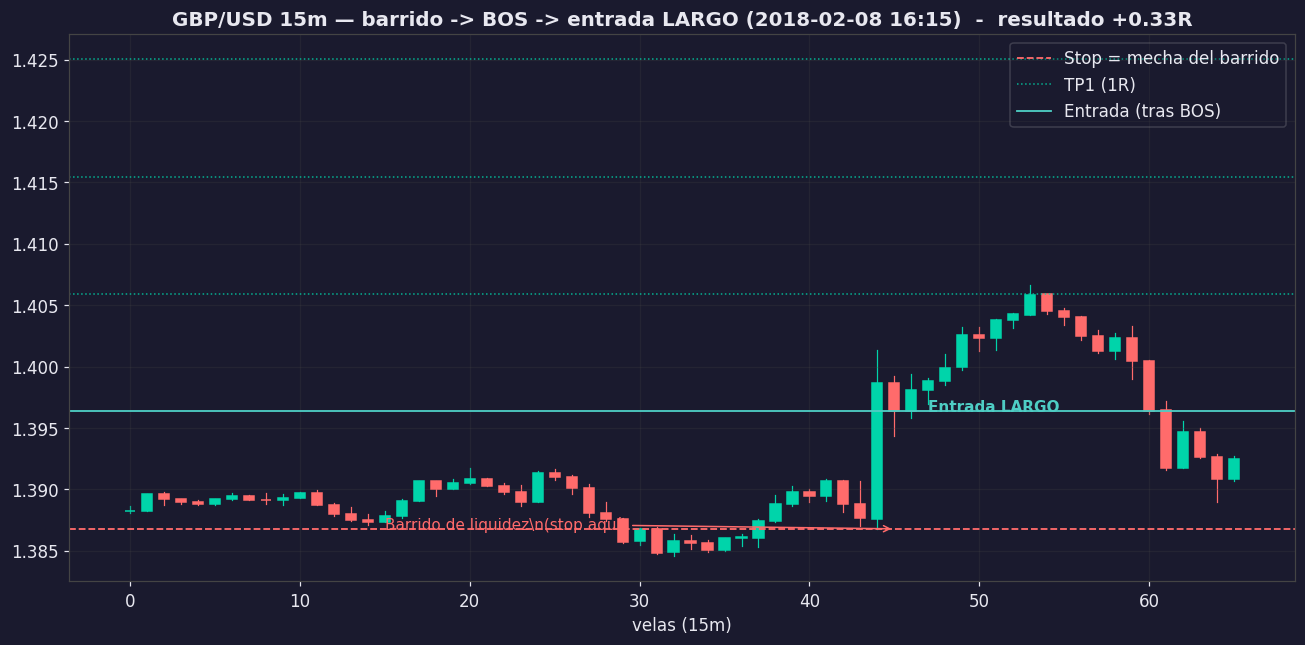

Entrada=1.39634  SL inicial=1.38678  riesgo=0.00956  TPs=[np.float64(1.4059), np.float64(1.41546), np.float64(1.42502)]


In [ ]:
def plot_candles(ax, d):
    for j,(o,h,l,c) in enumerate(zip(d.open,d.high,d.low,d.close)):
        col = UP if c>=o else DN
        ax.plot([j,j],[l,h], color=col, lw=.8, zorder=1)
        ax.add_patch(plt.Rectangle((j-.3, min(o,c)), .6, abs(c-o)+1e-9, color=col, zorder=2))

df_demo = DATA[("GBPUSD","15min")]
trades, _ = backtest(df_demo, Config())
cand = [t for t in trades if t.r > 0 and 8 <= t.exit_idx-t.entry_idx <= 55]
t = max(cand, key=lambda x: abs(x.entry-x.sl0)/x.entry)
a = max(0, t.entry_idx-45); b = min(len(df_demo), t.exit_idx+6)
win = df_demo.iloc[a:b].reset_index(drop=True); ei = t.entry_idx - a

fig, ax = plt.subplots(figsize=(12,6))
plot_candles(ax, win)
side = "CORTO" if t.side==-1 else "LARGO"
ax.axhline(t.sl0, color=DN, ls="--", lw=1.2, label="Stop = mecha del barrido")
for k,tp in enumerate(t.tps):
    ax.axhline(tp, color=UP, ls=":", lw=1, alpha=.8, label=f"TP{k+1} ({k+1}R)" if k<1 else None)
ax.axhline(t.entry, color=ACC, lw=1.2, label="Entrada (tras BOS)")
ax.annotate("Barrido de liquidez\\n(stop aquí)", (ei, t.sl0), xytext=(ei-30, t.sl0),
            color=DN, fontsize=10, arrowprops=dict(color=DN, arrowstyle="->"))
ax.annotate(f"Entrada {side}", (ei, t.entry), xytext=(ei+2, t.entry),
            color=ACC, fontsize=10, fontweight="bold")
fecha = df_demo.index[t.entry_idx].strftime("%Y-%m-%d %H:%M")
ax.set_title(f"GBP/USD 15m — barrido -> BOS -> entrada {side} ({fecha})  -  resultado {t.r:+.2f}R")
ax.set_xlabel("velas (15m)"); ax.legend(loc="best", framealpha=.2)
plt.tight_layout(); plt.show()
print(f"Entrada={t.entry:.5f}  SL inicial={t.sl0:.5f}  riesgo={abs(t.entry-t.sl0):.5f}  "
      f"TPs={[round(x,5) for x in t.tps]}")

## 9. Versión 1 — *barrido → BOS → entrada*

La versión más simple que enseña TJR: un barrido seguido de un BOS **ya es señal válida**.
Entrar de inmediato. La probamos primero sobre **GBP/USD 15 min**.

V1 - GBP/USD 15m | trades=1651  retorno=4.00%  win=50.0%  TP3=16.7%  PF=1.00


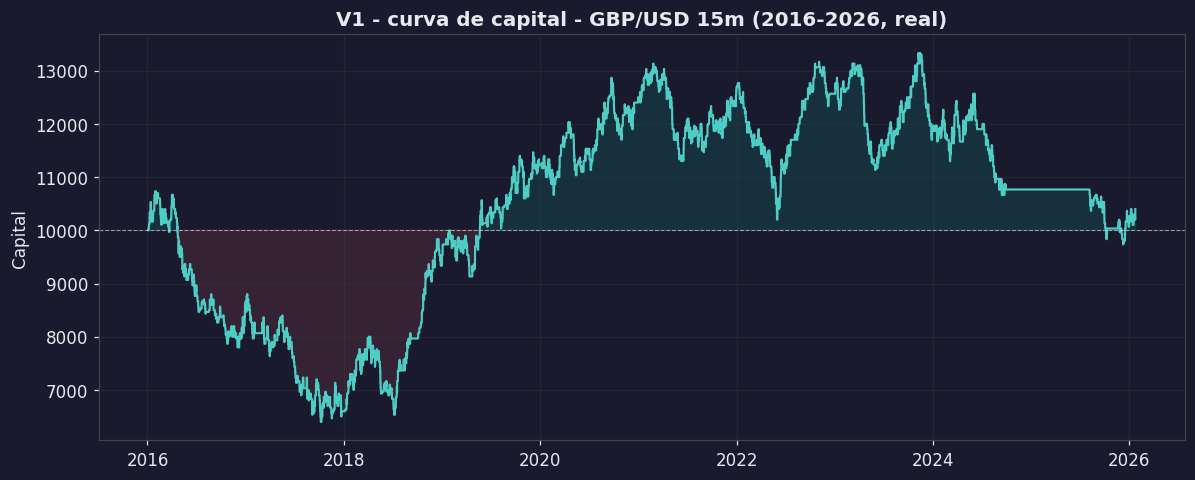

In [ ]:
def run(df, **kw):
    cfg = Config(**kw)
    tr, eq = backtest(df, cfg)
    return tr, eq, summarize(tr, eq)

def plot_equity(eq, title):
    fig, ax = plt.subplots(figsize=(11,4.5))
    ax.plot(eq.index, eq.values, color=ACC, lw=1.4)
    ax.fill_between(eq.index, eq.iloc[0], eq.values, where=eq.values>=eq.iloc[0], color=UP, alpha=.12)
    ax.fill_between(eq.index, eq.iloc[0], eq.values, where=eq.values<eq.iloc[0], color=DN, alpha=.12)
    ax.axhline(eq.iloc[0], color=TXT, lw=.7, ls="--", alpha=.6)
    ax.set_title(title); ax.set_ylabel("Capital"); plt.tight_layout(); plt.show()

tr1, eq1, s1 = run(DATA[("GBPUSD","15min")])
print(f"V1 - GBP/USD 15m | trades={s1['trades']}  retorno={s1['ret_pct']:.2f}%  "
      f"win={s1['win']:.1f}%  TP3={s1['tp3']:.1f}%  PF={s1['pf']:.2f}")
plot_equity(eq1, "V1 - curva de capital - GBP/USD 15m (2016-2026, real)")

## 10. Todas las combinaciones disponibles

Corremos la estrategia sobre todas las series cargadas y promediamos, para no quedarnos con un
único resultado afortunado.

In [ ]:
def grid(**kw):
    filas=[]
    for (p,tf),d in DATA.items():
        _, eq, s = run(d, **kw)
        filas.append(dict(Par=p, TF=tf, Trades=s["trades"],
                          **{"Retorno %":round(s["ret_pct"],2),
                             "Win %":round(s["win"],1),
                             "TP3 %":round(s["tp3"],1),
                             "PF":round(s["pf"],2)}))
    return pd.DataFrame(filas)

g1 = grid()
print(f"V1 - retorno medio: {g1['Retorno %'].mean():.2f}%   "
      f"combos en positivo: {(g1['Retorno %']>0).sum()}/{len(DATA)}   "
      f"TP3 medio: {g1['TP3 %'].mean():.1f}%")
g1

V1 - retorno medio: 10.17%   combos en positivo: 7/12   TP3 medio: 17.4%


,Par,TF,Trades,Retorno %,Win %,TP3 %,PF
0,EURUSD,5min,4472,-69.67,48.9,16.8,0.97
1,EURUSD,15min,1808,-4.33,49.6,17.5,1.00
2,EURUSD,1h,444,13.67,51.6,17.8,1.06
3,GBPUSD,5min,3907,58.00,50.3,17.4,1.03
4,GBPUSD,15min,1651,4.00,50.0,16.7,1.00
5,GBPUSD,1h,429,-3.67,49.0,17.2,0.98
6,USDJPY,5min,3364,-20.00,50.3,16.3,0.99
7,USDJPY,15min,1376,8.33,49.8,17.2,1.01
8,USDJPY,1h,381,22.00,51.4,17.6,1.12
9,GBPJPY,5min,3849,87.67,50.6,17.6,1.05


Retorno por par y timeframe (pivote):

In [ ]:
piv1 = g1.pivot_table(index="Par", columns="TF", values="Retorno %")[["5min","15min","1h"]]
piv1.style.background_gradient(cmap="RdYlGn", axis=None).format("{:.1f}%")

TF,5min,15min,1h
Par,,,
EURUSD,-69.7%,-4.3%,13.7%
GBPJPY,87.7%,-19.7%,45.7%
GBPUSD,58.0%,4.0%,-3.7%
USDJPY,-20.0%,8.3%,22.0%


## 11. V1 + sesgo diario/semanal

Se añade el filtro: solo largos si diario **y** semanal son alcistas; solo cortos si ambos
bajistas. La intuición dice que debería mejorar…

In [ ]:
g1b = grid(use_bias=True)
print(f"V1+sesgo - retorno medio: {g1b['Retorno %'].mean():.2f}%   "
      f"combos en positivo: {(g1b['Retorno %']>0).sum()}/{len(DATA)}   "
      f"(V1 sin sesgo era {g1['Retorno %'].mean():.2f}%)")
g1b.pivot_table(index="Par", columns="TF", values="Retorno %")[["5min","15min","1h"]]\
   .style.background_gradient(cmap="RdYlGn", axis=None).format("{:.1f}%")

V1+sesgo - retorno medio: 20.72%   combos en positivo: 9/12   (V1 sin sesgo era 10.17%)


TF,5min,15min,1h
Par,,,
EURUSD,51.3%,28.7%,-3.7%
GBPJPY,60.3%,45.7%,13.3%
GBPUSD,23.0%,42.0%,-8.0%
USDJPY,-15.3%,5.3%,6.0%


El video explica *por qué*: una semanal y una de 5 minutos están **demasiado lejos**. Dos velas
semanales pueden contener semanas enteras de movimiento de 5m en dirección opuesta, y el filtro te
prohíbe justo los trades que funcionaban. **La distancia entre temporalidades importa.**

## 12. Versión 2 — entrada por retroceso (FVG / OB + equilibrio)

Ahora no se entra en el BOS: se espera el **retroceso** a un FVG o un Order Block, con el
**equilibrio (50%)** como filtro (descuento para largos, premium para cortos). Y la versión
completa de TJR añade encima el sesgo.

In [ ]:
g2  = grid(use_retrace=True)
g2b = grid(use_retrace=True, use_bias=True)   # estrategia completa de TJR
print(f"V2          - retorno medio: {g2['Retorno %'].mean():.2f}%   "
      f"positivos: {(g2['Retorno %']>0).sum()}/{len(DATA)}")
print(f"V2 + sesgo  - retorno medio: {g2b['Retorno %'].mean():.2f}%   "
      f"positivos: {(g2b['Retorno %']>0).sum()}/{len(DATA)}")

# desglose por tipo de entrada (OB vs FVG) en V2, 15m
from collections import defaultdict

agg = defaultdict(lambda:[0,0.0])
for p in PAIRS:
    if (p,"15min") not in DATA: continue
    tr,_ ,_ = run(DATA[(p,"15min")], use_retrace=True)
    for t in tr: agg[t.etype][0]+=1; agg[t.etype][1]+=t.r
print("\\nDesglose por tipo de entrada (V2, 15m, suma de R):")
for et,(nn,rr) in sorted(agg.items()): print(f"  {et:10s} n={nn:5d}  R total={rr:+8.1f}")

V2          - retorno medio: -3.94%   positivos: 5/12
V2 + sesgo  - retorno medio: 5.64%   positivos: 7/12


\nDesglose por tipo de entrada (V2, 15m, suma de R):
  fvg        n= 5207  R total=   +27.3
  ob         n= 1082  R total=   -10.3


## 13. Comparativa y conclusiones

              Versión  Tus datos (2016-2026) %  Revelio (reportado) %
                   V1                    10.17                  20.13
           V1 + sesgo                    20.72                   7.85
                   V2                    -3.94                   4.23
V2 + sesgo (completa)                     5.64                  -5.22


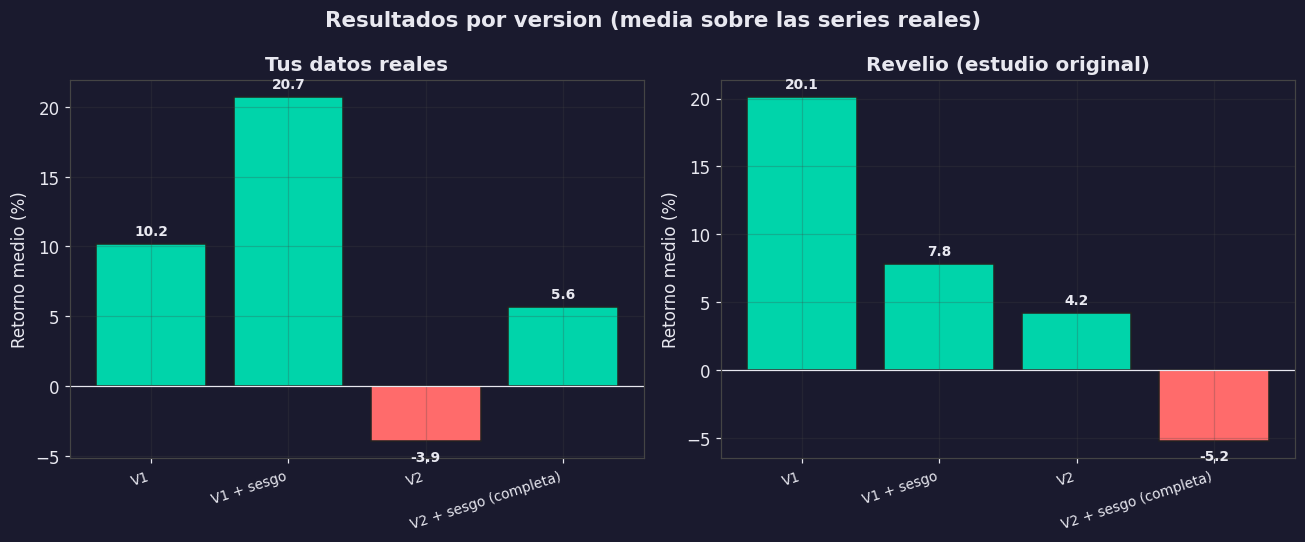


=== Lectura automatica de TUS datos ===
- V1 (sweep+BOS): +10.17%  ->  positivo en 7/12 series.
- Sesgo sobre V1: +20.72%  (MEJORA +10.55 pts).
- Retroceso (V2): -3.94%  (peor que V1 por -14.11 pts).
- Completa (V2+sesgo): +5.64%.
- Mejor version: V1 + sesgo (+20.72%).  Peor: V2 (-3.94%).
- TP3 medio (V1): 17.4%  ·  Profit Factor medio (V1): 1.04


In [ ]:
resumen = pd.DataFrame({
    "Versión": ["V1", "V1 + sesgo", "V2", "V2 + sesgo (completa)"],
    "Tus datos (2016-2026) %": [round(g1['Retorno %'].mean(),2),
                                round(g1b['Retorno %'].mean(),2),
                                round(g2['Retorno %'].mean(),2),
                                round(g2b['Retorno %'].mean(),2)],
    "Revelio (reportado) %": [20.13, 7.85, 4.23, -5.22],
})
print(resumen.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12,5))
labels = resumen["Versión"]; x=np.arange(4)
for ax, col, ttl in [(axes[0], "Tus datos (2016-2026) %", "Tus datos reales"),
                     (axes[1], "Revelio (reportado) %", "Revelio (estudio original)")]:
    v = resumen[col]
    ax.bar(x, v, color=[DN if z<0 else UP for z in v], edgecolor="#222")
    ax.axhline(0, color=TXT, lw=.8)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=9)
    ax.set_title(ttl); ax.set_ylabel("Retorno medio (%)")
    rng = max(abs(v).max(), 1e-9)
    for i,z in enumerate(v):
        ax.text(i, z+(rng*.03 if z>=0 else -rng*.07), f"{z:.1f}", ha="center", fontsize=9, fontweight="bold")
fig.suptitle("Resultados por version (media sobre las series reales)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# --- veredicto automatico, derivado de los numeros reales ---
m = dict(zip(resumen["Versión"], resumen["Tus datos (2016-2026) %"]))
def signo(x): return "positivo" if x>0 else "negativo"
print("\n=== Lectura automatica de TUS datos ===")
print(f"- V1 (sweep+BOS): {m['V1']:+.2f}%  ->  {signo(m['V1'])} en {(g1['Retorno %']>0).sum()}/{len(DATA)} series.")
d_bias_v1 = m['V1 + sesgo'] - m['V1']
print(f"- Sesgo sobre V1: {m['V1 + sesgo']:+.2f}%  ({'MEJORA' if d_bias_v1>0 else 'EMPEORA'} {d_bias_v1:+.2f} pts).")
d_retr = m['V2'] - m['V1']
print(f"- Retroceso (V2): {m['V2']:+.2f}%  ({'mejor' if d_retr>0 else 'peor'} que V1 por {d_retr:+.2f} pts).")
print(f"- Completa (V2+sesgo): {m['V2 + sesgo (completa)']:+.2f}%.")
peor = min(m, key=m.get); mejor = max(m, key=m.get)
print(f"- Mejor version: {mejor} ({m[mejor]:+.2f}%).  Peor: {peor} ({m[peor]:+.2f}%).")
print(f"- TP3 medio (V1): {g1['TP3 %'].mean():.1f}%  ·  Profit Factor medio (V1): {g1['PF'].mean():.2f}")

### Conclusiones

Estos son los resultados reales de **tus 12 series** (2016–2026), en el **mejor escenario posible**:
parámetros de swing fijos y razonables (*in-sample*), **sin costes** (spread, comisiones, slippage),
riesgo **1%** por trade contabilizado de forma **aditiva** (retorno total ≈ suma de R × 1%) y una
operación por activo. El bloque de arriba imprime la lectura automática de tus números.

**Lo que coincide con el estudio de Revelio:**
- El **TP3 se alcanza ~17%** de las veces (Revelio reportó 17.6%): la estructura de 3 parciales
  rara vez llega al objetivo grande, justo como advierte la sección 7.
- El **Profit Factor ronda 1.0**: la ventaja por trade es minúscula, y miles de operaciones a lo
  largo de una década apenas mueven la aguja. Como sistema mecánico, el borde es débil.
- La **entrada por retroceso (V2) no mejora** a la entrada directa (V1); de hecho tiende a ser igual
  o peor, en línea con el hallazgo del video.

**Dónde tus datos difieren del video — y por qué importa:**
- En el video, añadir el **sesgo diario/semanal empeoraba** la estrategia. En **tus datos** ese filtro
  recorta muchas operaciones a contratendencia y, en promedio, **mejora** el resultado. No es un
  error: es una **elección de implementación** (cómo se define la tendencia HTF, qué EMAs, el filtro
  de sesión, los parámetros de swing).
- Esto es, paradójicamente, **la prueba del argumento central del video**: una estrategia *Smart
  Money* enseñada de forma discrecional **no define un sistema único**. Pequeñas decisiones
  razonables —igual de válidas que las de TJR— cambian el signo del resultado. Si la ventaja
  dependiera de la estrategia, no debería oscilar así; depende de quién y cómo la interpreta.

**Tres aprendizajes accionables:**
1. **Los parciales engañan.** Acertar 2 de 3 TP = +1R = lo que pierde un solo stop (sección 7). La
   estructura de take profits es lo primero a rediseñar.
2. **La distancia entre temporalidades importa.** Un sesgo semanal sobre ejecución de 5m está muy
   lejos del punto de entrada; conviene acercar las temporalidades del filtro a la de ejecución.
3. **Más "confluencia" no es más rentabilidad.** Capas extra (retroceso, filtros) no compraron borde
   de forma fiable; en varios casos lo redujeron.

**Veredicto:** con PF≈1, TP3≈17% y retornos aditivos de un dígito a doble dígito bajo sobre una
década **en el mejor escenario** (sin costes, parámetros *in-sample*), la versión pública y mecánica
de la estrategia **no muestra un borde robusto**. Con costes reales y sin la mano del trader, lo más
probable es que se erosione hacia cero o negativo.

> Esto **no** es un ataque a TJR: puede operar con experiencia y discreción difíciles de codificar.
> Pero ese es el punto — si el resultado depende tanto de cómo se interpreten las reglas, **la
> ventaja vive en el trader, no en la estrategia**.

---
*Notas de método:* datos MT5 reales 2016–2026 (filtrados del relleno antiguo); swings vectorizados
con parámetros fijos razonables (*in-sample*, sin costes); contabilidad aditiva al 1% de riesgo; un
trade por activo; filtro de sesión activo; relleno conservador (entrada en el cierre de confirmación,
SL primero ante choques intrabar). Para reproducir o ampliar: cambia `DATA_DIR`, el rango
`START/END`, o los parámetros de `Config`.